In [2]:
import ee
ee.Authenticate()  # Opens browser, paste your token
ee.Initialize(project='gen-lang-client-0768135868')  


Successfully saved authorization token.


In [3]:
import ee
import geemap
import geopandas as gpd
from pathlib import Path
import os
from dotenv import load_dotenv

# Load environment
load_dotenv()
DATA_DIR = Path(os.getenv('DATA_DIR'))
RAW_DATA = DATA_DIR / 'sumatra-deforestation/raw'
PROCESSED_DATA = DATA_DIR / 'sumatra-deforestation/processed'

# Initialize Earth Engine
ee.Initialize(project='gen-lang-client-0768135868')  # Replace with your project ID

print("✓ Earth Engine initialized")

✓ Earth Engine initialized


## Load Sumatra Boundary

In [11]:
# Load Sumatra boundary from earlier (or download again)
sumatra_boundary_path = RAW_DATA / 'sumatra_boundary.geojson'

if sumatra_boundary_path.exists():
    sumatra_gdf = gpd.read_file(sumatra_boundary_path)
else:
    # Download Indonesia provinces
    url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_1.json"
    indonesia_adm1 = gpd.read_file(url)

    sumatra_provinces = [
        'Aceh', 'SumateraUtara', 'SumateraBarat', 'Riau', 
        'Jambi', 'SumateraSelatan', 'Bengkulu', 'Lampung',
        'BangkaBelitung', 'KepulauanRiau'
    ]

sumatra_gdf = indonesia_adm1[indonesia_adm1['NAME_1'].isin(sumatra_provinces)]
sumatra_gdf.to_file(sumatra_boundary_path, driver='GeoJSON')

# Convert to Earth Engine geometry
sumatra_ee = geemap.geopandas_to_ee(sumatra_gdf)

print(f"✓ Loaded Sumatra boundary: {len(sumatra_gdf)} provinces")
print(f"Bounds: {sumatra_gdf.total_bounds}")

✓ Loaded Sumatra boundary: 10 provinces
Bounds: [ 95.0097  -6.1686 109.1638   6.0761]


## Load Hansen Data and Calculate Annual Loss

In [17]:
# Load Hansen dataset
hansen = ee.Image('UMD/hansen/global_forest_change_2024_v1_12')

# Extract bands
treecover2000 = hansen.select('treecover2000')
lossyear = hansen.select('lossyear')

# Clip to Sumatra
treecover_sumatra = treecover2000.clip(sumatra_ee)
lossyear_sumatra = lossyear.clip(sumatra_ee)

# Calculate area per year (in hectares)
pixel_area = ee.Image.pixelArea().divide(10000)  # Convert m² to hectares

def calculate_loss_for_year(year):
    """Calculate forest loss for specific year"""
    year = ee.Number(year)
    year_code = year.subtract(2000)
    
    loss_mask = lossyear_sumatra.eq(year_code)
    loss_area = loss_mask.multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=sumatra_ee,
        scale=300,
        maxPixels=1e13
    )
    return ee.Feature(None, {
        'year': year,
        'forest_loss_hectares': loss_area.get('lossyear')
    })
# Calculate for all years
years = ee.List.sequence(2001, 2024)
loss_by_year = ee.FeatureCollection(years.map(calculate_loss_for_year))

print("✓ Calculated annual forest loss for 2001-2024")

✓ Calculated annual forest loss for 2001-2024


## Export Results

In [18]:
# Export to Google Drive
task = ee.batch.Export.table.toDrive(
    collection=loss_by_year,
    description='sumatra_forest_loss_300m',
    fileFormat='CSV'
)

task.start()
print("✓ Export started")
print("Monitor: https://code.earthengine.google.com/tasks")


✓ Export started
Monitor: https://code.earthengine.google.com/tasks


In [23]:

from datetime import datetime

# Export tree cover 2000
export_treecover = ee.batch.Export.image.toDrive(
    image=treecover_sumatra,
    description='sumatra_treecover2000',
    scale=300,
    region=sumatra_ee.geometry(),
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

# Export lossyear
export_lossyear = ee.batch.Export.image.toDrive(
    image=lossyear_sumatra,
    description='sumatra_lossyear',
    scale=300,
    region=sumatra_ee.geometry(),
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

export_treecover.start()
export_lossyear.start()

print("✓ Exporting rasters to Google Drive (~5-10 min)")
print("Monitor: https://code.earthengine.google.com/tasks")

✓ Exporting rasters to Google Drive (~5-10 min)
Monitor: https://code.earthengine.google.com/tasks


## Load GEE results

In [20]:
PROCESSED_DATA

PosixPath('/Users/mrla/Documents/Projects/data/sumatra-deforestation/processed')

In [22]:

import pandas as pd

loss_df = pd.read_csv(PROCESSED_DATA / 'sumatra_forest_loss_300m.csv')
loss_df = loss_df.sort_values('year')

print(f"✓ Loaded {len(loss_df)} years")
print(f"\nTotal loss 2001-2024: {loss_df['forest_loss_hectares'].sum():,.0f} hectares")
print("\nFirst 10 years:")
print(loss_df.head(10))

✓ Loaded 24 years

Total loss 2001-2024: 15,492,579 hectares

First 10 years:
   system:index  forest_loss_hectares    year  \
0             0         384716.504975  2001.0   
1             1         366509.065053  2002.0   
2             2         187382.652606  2003.0   
3             3         662296.841927  2004.0   
4             4         717634.656935  2005.0   
5             5         705382.484896  2006.0   
6             6         702520.493148  2007.0   
7             7         764118.384569  2008.0   
8             8         955569.180196  2009.0   
9             9         731735.974070  2010.0   

                                     .geo  
0  {"type":"MultiPoint","coordinates":[]}  
1  {"type":"MultiPoint","coordinates":[]}  
2  {"type":"MultiPoint","coordinates":[]}  
3  {"type":"MultiPoint","coordinates":[]}  
4  {"type":"MultiPoint","coordinates":[]}  
5  {"type":"MultiPoint","coordinates":[]}  
6  {"type":"MultiPoint","coordinates":[]}  
7  {"type":"MultiPoint","coord

In [24]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load rasters
treecover_path = PROCESSED_DATA / 'sumatra_treecover2000.tif'
lossyear_path = PROCESSED_DATA / 'sumatra_lossyear.tif'

with rasterio.open(treecover_path) as src:
    treecover_data = src.read(1)
    
with rasterio.open(lossyear_path) as src:
    lossyear_data = src.read(1)

# Downsample for faster plotting (every 5th pixel)
downsample = 5
small_treecover = treecover_data[::downsample, ::downsample]
small_lossyear = lossyear_data[::downsample, ::downsample]

print(f"Original: {treecover_data.shape}, Downsampled: {small_treecover.shape}")

Original: (4545, 5253), Downsampled: (909, 1051)


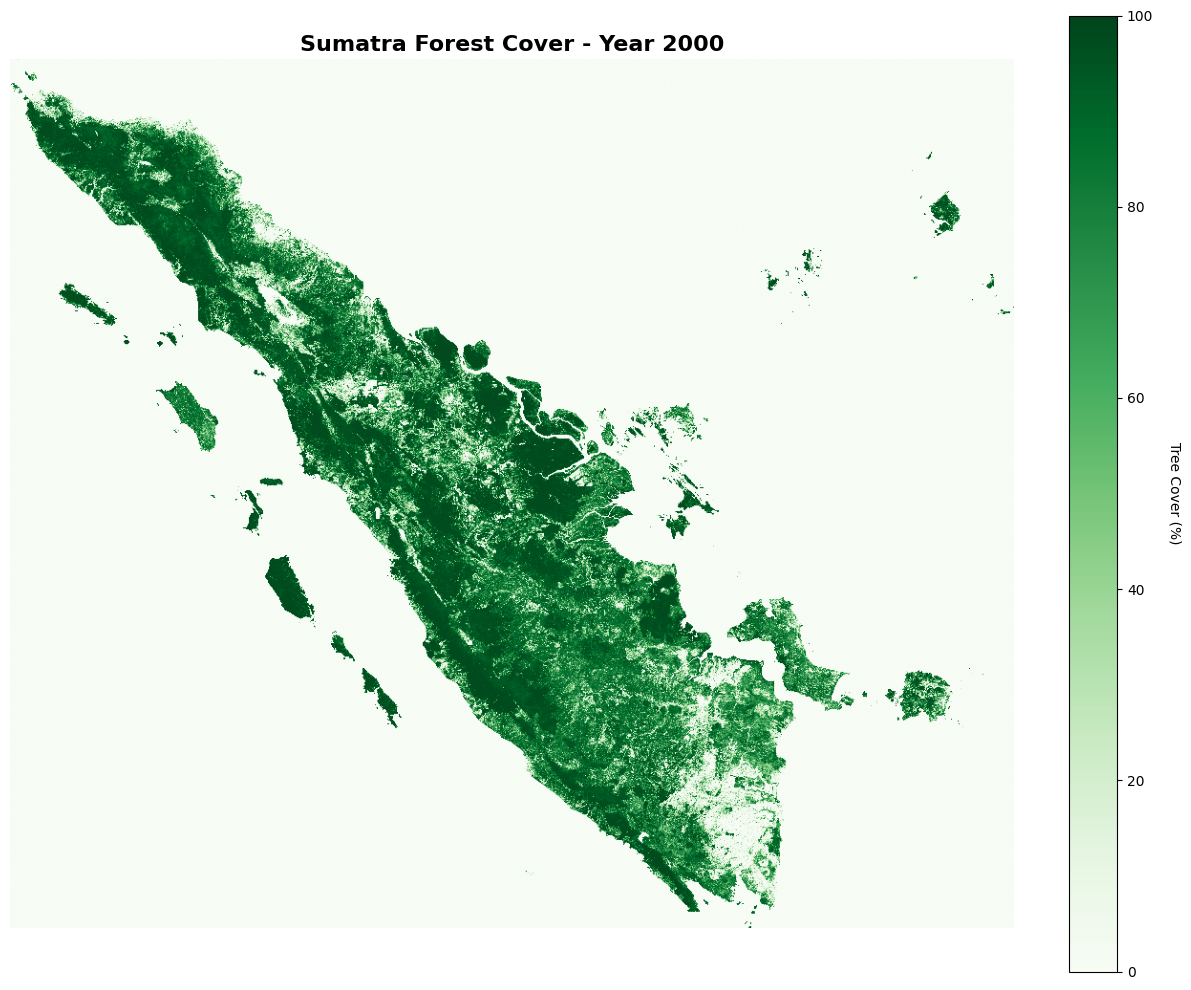

In [25]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(small_treecover, cmap='Greens', vmin=0, vmax=100)
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('Tree Cover (%)', rotation=270, labelpad=20)
ax.set_title('Sumatra Forest Cover - Year 2000', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()

output_path = PROCESSED_DATA.parent / 'outputs' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path / 'sumatra_forest_2000_gee.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualize cumulative loss

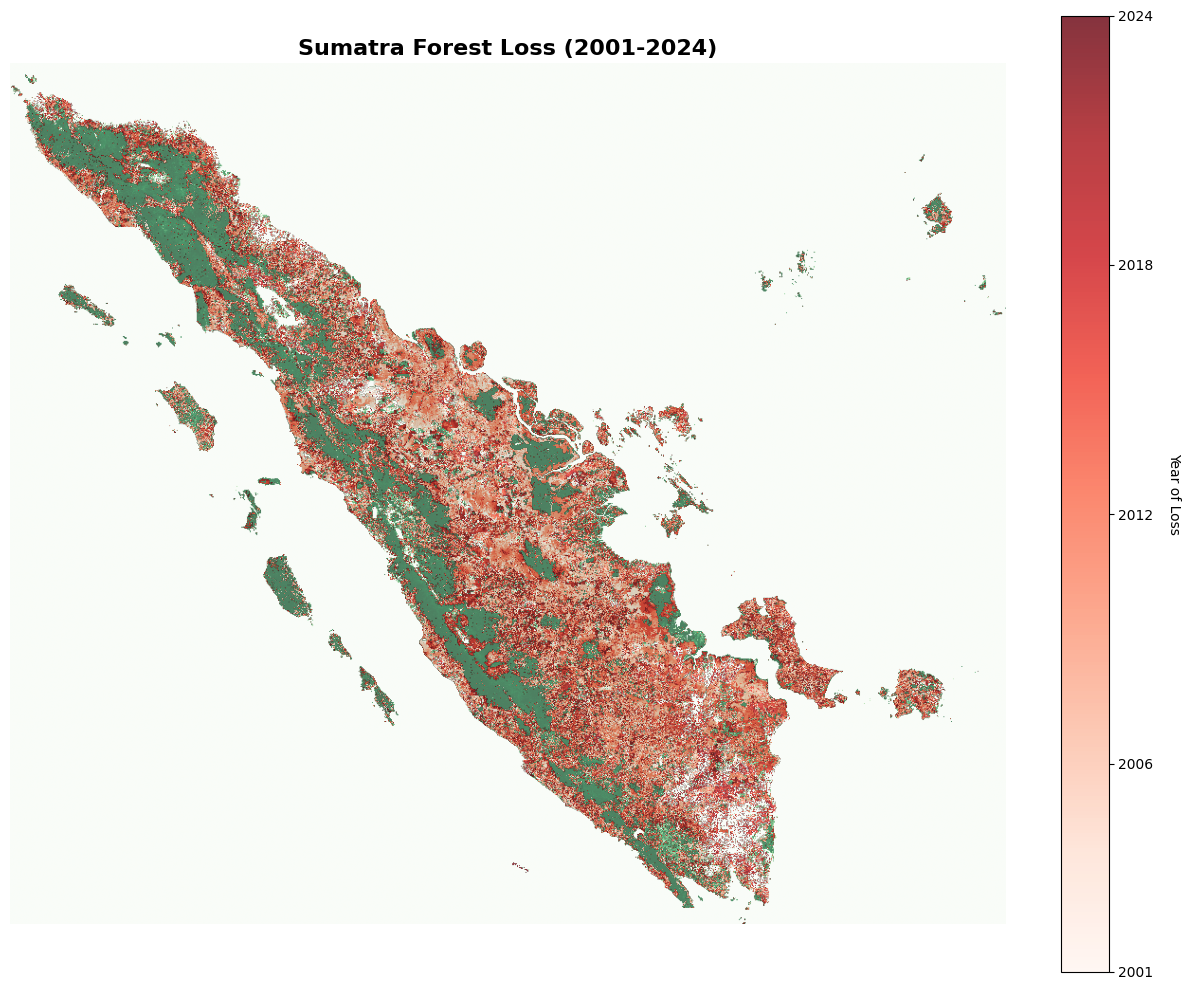

In [26]:
fig, ax = plt.subplots(figsize=(12, 10))

# Forest base
forest_base = np.where(small_treecover > 30, small_treecover, 0)
ax.imshow(forest_base, cmap='Greens', vmin=0, vmax=100, alpha=0.7)

# Loss overlay
loss_mask = small_lossyear > 0
loss_overlay = np.ma.masked_where(~loss_mask, small_lossyear)
im = ax.imshow(loss_overlay, cmap='Reds', vmin=1, vmax=24, alpha=0.8)

cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('Year of Loss', rotation=270, labelpad=20)
cbar.set_ticks([1, 6, 12, 18, 24])
cbar.set_ticklabels(['2001', '2006', '2012', '2018', '2024'])

ax.set_title('Sumatra Forest Loss (2001-2024)', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(output_path / 'sumatra_forest_loss_cumulative_gee.png', dpi=300, bbox_inches='tight')
plt.show()

### Create annual loss maps

In [ ]:
from tqdm import tqdm

def create_cumulative_map_with_stats(year):
    year_code = year - 2000
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Calculate remaining forest
    remaining_forest = small_treecover.copy()
    lost_by_year = (small_lossyear > 0) & (small_lossyear <= year_code)
    remaining_forest[lost_by_year] = 0
    
    forest_mask = remaining_forest > 30
    forest_display = np.ma.masked_where(~forest_mask, remaining_forest)
    ax.imshow(forest_display, cmap='Greens', vmin=0, vmax=100)
    
    # Calculate cumulative loss
    cumulative_loss = loss_df[loss_df['year'] <= year]['forest_loss_hectares'].sum()
    loss_km2 = cumulative_loss / 100
    
    # Add text box with stats
    textstr = f'Year: {year}\nCumulative Loss: {loss_km2:,.0f} km²'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', bbox=props)
    
    ax.text(0.98, 0.02, 'Analysis: Rake Anggoro', 
        transform=ax.transAxes, fontsize=9,
        ha='right', va='bottom', alpha=0.5)
    
    ax.set_title(f'Remaining Sumatra Forest - {year}', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    annual_dir = output_path / 'annual_cumulative'
    annual_dir.mkdir(exist_ok=True)
    plt.savefig(annual_dir / f'forest_{year}.png', dpi=150, bbox_inches='tight')
    plt.close()

for year in tqdm(range(2000, 2025), desc="Creating cumulative maps"):
    create_cumulative_map_with_stats(year)


Creating cumulative maps: 100%|██████████| 25/25 [00:06<00:00,  4.07it/s]


### Create MP4

In [37]:
import subprocess

input_pattern = str(output_path / 'annual_cumulative' / 'forest_%04d.png')
output_video = str(output_path / 'sumatra_deforestation.mp4')

# Use ffmpeg (install with: brew install ffmpeg)
subprocess.run([
    'ffmpeg', '-y',
    '-framerate', '2',  # 2 frames per second
    '-start_number', '2000',
    '-i', input_pattern,
    '-c:v', 'libx264',
    '-pix_fmt', 'yuv420p',
    output_video
])

print(f"✓ Video created: {output_video}")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

✓ Video created: /Users/mrla/Documents/Projects/data/sumatra-deforestation/outputs/figures/sumatra_deforestation.mp4


[out#0/mp4 @ 0x13d72e9d0] video:1489KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.066688%
frame=   25 fps=0.0 q=-1.0 Lsize=    1490KiB time=00:00:11.50 bitrate=1061.6kbits/s speed=50.3x    
[libx264 @ 0x13d72f8f0] frame I:1     Avg QP:12.26  size:220069
[libx264 @ 0x13d72f8f0] frame P:23    Avg QP:19.45  size: 55365
[libx264 @ 0x13d72f8f0] frame B:1     Avg QP:22.32  size: 30843
[libx264 @ 0x13d72f8f0] consecutive B-frames: 92.0%  8.0%  0.0%  0.0%
[libx264 @ 0x13d72f8f0] mb I  I16..4: 31.5% 43.2% 25.3%
[libx264 @ 0x13d72f8f0] mb P  I16..4:  0.1%  0.0%  0.4%  P16..4: 18.1%  0.4%  1.3%  0.0%  0.0%    skip:79.6%
[libx264 @ 0x13d72f8f0] mb B  I16..4:  0.2%  0.3%  0.0%  B16..8:  9.1%  4.0%  6.1%  direct: 3.6%  skip:76.6%  L0:46.3% L1:47.9% BI: 5.8%
[libx264 @ 0x13d72f8f0] 8x8 transform intra:39.1% inter:0.7%
[libx264 @ 0x13d72f8f0] coded y,uvDC,uvAC intra: 28.2% 30.2% 29.1% inter: 11.5% 16.7% 15.3%
[libx264 @ 0x13d72f8f0] i16 v,h,dc,p: 89%  6%  5%  1

In [35]:
print(f"Total loss: {loss_df['forest_loss_hectares'].sum():,.0f} hectares")
print(f"That's {loss_df['forest_loss_hectares'].sum() / 100:,.0f} km²")
print("Sumatra Island (+ surrounding small islands) ~482,286 km²")

Total loss: 15,492,579 hectares
That's 154,926 km²
Sumatra Island (+ surrounding small islands) ~482,286 km²
